In [32]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

from pha_lib import io
from pha_lib.discharges import detect_injections, InjectionDetectionConfig
from pha_lib.fit import fit_injection
from pha_lib.model import Discharge, TimeTrace, Injection, FitResult
from pha_lib.plotting import plot_timetrace_with_injections, plot_injection_fit
from pha_lib.timetrace import integrate_energy_window

plt.rcParams["figure.dpi"] = 120

# Notebook Map (What Each Cell Does)

This notebook is organized as an exploratory, notebook-first workflow around injection analysis.

1. **Cell 1**: Imports and plotting defaults.
2. **Cell 2**: Core reusable logic:
   - config dataclass,
   - single-discharge and cross-discharge plotting functions,
   - adaptive module loader,
   - main `run_big_eye(...)` orchestration.
3. **Cell 3**: Main analysis run (test discharge + multi-discharge load and run).
4. **Cell 4**: Quick re-plot with fixed axis limits.
5. **Cell 5**: Points-only version of the cross-discharge view.
6. **Cell 6**: 2D histogram density map.
7. **Cell 7**: Smoothed KDE density map in `(frame offset, events)` space.
8. **Cell 8**: Histograms of injection peak values with multiple bin widths.
9. **Cell 9**: Smoothed 1D KDE + cumulative distribution for peak values.
10. **Cell 10**: Line plot for injections filtered by peak threshold.
11. **Cell 11**: Line plot for injections filtered by `(length >= 4 and peak < threshold)`.
12. **Cell 12**: Cross-discharge style plot for injections filtered by `length >= 4`.
13. **Cell 13**: Cell-9 style KDE/CDF for injections with `length > 4` using existing filtered set.
14. **Cell 14**: Scratch/empty cell for ad-hoc checks.

Notes:
- Most later cells reuse variables built in Cell 3.
- Plot-only cells are intended to avoid re-running expensive detection/fitting when not needed.

In [ ]:
@dataclass
class BigEyeConfig:
    # Energy window used to build per-frame time traces.
    line_energy_eV: float = 6660.0
    half_window_eV: float = 60
    # Fallback fixed-point fit settings.
    n_points: int = 3
    # Adaptive fit bounds.
    adaptive_min_points: int = 3
    adaptive_max_points: int = 15


def plot_all_injections_one_graph(
    trace: TimeTrace,
    injections: Sequence[Injection],
    normalize_to_start: bool = False,
    alpha: float = 0.9,
    x_max_offset: float | None = None,
    ax: plt.Axes | None = None,
    title: str | None = None,
) -> plt.Axes:
    """Overlay points of all injections on one graph, aligned by start frame."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    fn = trace.frame_numbers
    y = trace.values
    plotted = 0
    max_offset_seen = 0.0

    for inj in injections:
        # Keep only samples inside one injection window.
        mask = (fn >= inj.start_frame) & (fn <= inj.finish_frame)
        if not np.any(mask):
            continue

        # Align each injection to local x=0 at its start.
        x_local = fn[mask].astype(float) - float(inj.start_frame)
        y_local = y[mask].astype(float)
        if normalize_to_start:
            # Optional baseline normalization for shape comparison.
            y_local = y_local - y_local[0]

        if x_local.size > 0:
            max_offset_seen = max(max_offset_seen, float(np.max(x_local)))

        ax.plot(
            x_local,
            y_local,
            "o-",
            ms=5.5,
            lw=2.4,
            alpha=alpha,
            label=f"inj #{inj.injection_no}",
        )
        plotted += 1

    lo, hi = trace.energy_window_eV
    ax.set_title(title or f"All injections overlay (ch {trace.channel_id}, N={plotted}, window [{lo:.0f}, {hi:.0f}] eV)")
    ax.set_xlabel("frame offset from injection start")
    ax.set_ylabel("events" + (" (delta from start)" if normalize_to_start else ""))

    if x_max_offset is None:
        x_max_offset = max_offset_seen
    x_hi = max(float(x_max_offset), max_offset_seen, 1.0)
    ax.set_xlim(0, x_hi)

    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=16, integer=True))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
    ax.minorticks_on()
    ax.grid(which="major", alpha=0.65, linewidth=1.0)
    ax.grid(which="minor", alpha=0.30, linestyle=":", linewidth=0.8)

    if plotted > 0:
        ax.legend(loc="best", fontsize=9, ncol=2, framealpha=0.9)

    return ax


def plot_injections_across_discharges(
    results_by_discharge: dict[str, dict],
    channel_id: int = 2,
    injection_numbers: Sequence[int] | None = None,
    normalize_to_start: bool = False,
    ax: plt.Axes | None = None,
    title: str | None = None,
):
    """Overlay injections across multiple discharges.

    Visual encoding:
    - discharge -> base color (tab20, supports 16+ discharges) + unique marker
    - injections inside one discharge -> shades of that color (first = most saturated)
                                       + unique line style
    Legends are placed outside the axes on the right.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(14, 8))

    marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "H", "8", "p", "1", "2"]
    inj_linestyle_cycle = [
        "-",
        "--",
        "-.",
        ":",
        (0, (5, 1)),
        (0, (3, 1, 1, 1)),
        (0, (1, 1)),
        (0, (3, 2, 1, 2)),
    ]

    # Collect all injection numbers present for this channel.
    all_inj_numbers: set[int] = set()
    for r in results_by_discharge.values():
        injs = r["detections"].get(channel_id, [])
        all_inj_numbers.update(int(i.injection_no) for i in injs)

    if injection_numbers is None:
        inj_numbers = sorted(all_inj_numbers)
    else:
        inj_numbers = [int(n) for n in injection_numbers]

    if not inj_numbers:
        ax.set_title("No injections to plot")
        return ax

    discharge_names = list(results_by_discharge.keys())

    # tab20 has 20 unique colors; for >20 discharges wrap around.
    base_cmap = plt.get_cmap("tab20")
    marker_by_discharge = {
        name: marker_cycle[i % len(marker_cycle)]
        for i, name in enumerate(discharge_names)
    }
    base_color_by_discharge = {
        name: base_cmap(i % base_cmap.N)
        for i, name in enumerate(discharge_names)
    }

    def _shade_from_base(base_rgba, level: float):
        """Blend base color toward white. level=1.0 -> full color, level=0.0 -> white."""
        level = float(np.clip(level, 0.0, 1.0))
        r, g, b, a = base_rgba
        return (
            1.0 - (1.0 - r) * level,
            1.0 - (1.0 - g) * level,
            1.0 - (1.0 - b) * level,
            a,
        )

    # Line style depends on injection number (same across all discharges).
    inj_linestyle_by_number = {
        inj_no: inj_linestyle_cycle[i % len(inj_linestyle_cycle)]
        for i, inj_no in enumerate(inj_numbers)
    }

    x_max = 1.0

    for d_name, r in results_by_discharge.items():
        marker = marker_by_discharge[d_name]
        base_color = base_color_by_discharge[d_name]

        trace = r["traces"].get(channel_id)
        if trace is None:
            continue

        fn = trace.frame_numbers
        y = trace.values
        injections = r["detections"].get(channel_id, [])
        inj_map = {int(inj.injection_no): inj for inj in injections}

        # Keep only globally selected injection numbers that exist for this discharge.
        inj_present = [n for n in inj_numbers if n in inj_map]
        if not inj_present:
            continue

        # Build per-injection shades inside one discharge (earlier = more saturated).
        n_local = len(inj_present)
        local_shades: dict[int, tuple] = {}
        for k, inj_no in enumerate(inj_present):
            level = 1.0 if n_local == 1 else 1.0 - 0.65 * (k / (n_local - 1))
            local_shades[inj_no] = _shade_from_base(base_color, level)

        for inj_no in inj_present:
            inj = inj_map[inj_no]
            mask = (fn >= inj.start_frame) & (fn <= inj.finish_frame)
            if not np.any(mask):
                continue

            # Local x-offset keeps injection starts aligned across discharges.
            x_local = fn[mask].astype(float) - float(inj.start_frame)
            y_local = y[mask].astype(float)
            if normalize_to_start:
                y_local = y_local - y_local[0]

            x_max = max(x_max, float(np.max(x_local)))

            ax.plot(
                x_local,
                y_local,
                marker=marker,
                linestyle=inj_linestyle_by_number[inj_no],
                color=local_shades[inj_no],
                lw=2.4,
                ms=6.0,
                alpha=0.95,
            )

    ax.set_xlim(0, x_max)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=16, integer=True))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
    ax.minorticks_on()
    ax.grid(which="major", alpha=0.65, linewidth=1.0)
    ax.grid(which="minor", alpha=0.30, linestyle=":", linewidth=0.8)
    ax.set_xlabel("frame offset from injection start")
    ax.set_ylabel("events" + (" (delta from start)" if normalize_to_start else ""))
    ax.set_title(title or f"Cross-discharge overlay, channel {channel_id}")

    # --- Legend 1 (outside right, top): discharge -> color + marker ---
    disch_handles = [
        Line2D(
            [0], [0],
            color=base_color_by_discharge[name],
            lw=2.4,
            linestyle="-",
            marker=marker_by_discharge[name],
            ms=6,
            label=name,
        )
        for name in discharge_names
    ]
    disch_leg = ax.legend(
        handles=disch_handles,
        title="Discharge",
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        fontsize=8,
        framealpha=0.9,
        borderaxespad=0.0,
    )
    ax.add_artist(disch_leg)

    # --- Legend 2 (outside right, below): injection number -> line style ---
    inj_style_handles = [
        Line2D(
            [0], [0],
            color="black",
            lw=2.4,
            linestyle=inj_linestyle_by_number[inj_no],
            label=f"inj #{inj_no}",
        )
        for inj_no in inj_numbers
        if inj_no in inj_linestyle_by_number
    ]
    ax.legend(
        handles=inj_style_handles,
        title="Injection (line style)",
        loc="upper left",
        bbox_to_anchor=(1.01, 0.42),
        fontsize=8,
        framealpha=0.9,
        borderaxespad=0.0,
    )

    return ax


def _load_adaptive_module():
    """Load adaptive points script module."""
    import importlib.util
    from pathlib import Path

    # Try a few common paths because notebook CWD can vary.
    candidates = [
        Path("adaptive points") / "adaptive point selection.py",
        Path.cwd() / "adaptive points" / "adaptive point selection.py",
        Path.cwd().parent / "adaptive points" / "adaptive point selection.py",
    ]
    script_path = next((p for p in candidates if p.exists()), None)
    if script_path is None:
        raise FileNotFoundError(
            "adaptive point selection.py not found. Tried: "
            + ", ".join(str(p) for p in candidates)
        )

    spec = importlib.util.spec_from_file_location("adaptive_point_selection", script_path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Cannot load module spec from {script_path}")

    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


def run_big_eye(
    discharge: Discharge,
    cfg: BigEyeConfig = BigEyeConfig(),
    channel_ids: Sequence[int] | None = None,
    detection_cfg: InjectionDetectionConfig | None = None,
    use_adaptive_fit: bool = True,
):
    """Graph-oriented runner using pha_lib.plotting and adaptive-points module."""
    if channel_ids is None:
        channel_ids = sorted(discharge.channels.keys())

    traces: dict[int, TimeTrace] = {}
    detections: dict[int, list[Injection]] = {}
    fits: dict[int, list[FitResult]] = {}
    rows: list[dict] = []

    # Resolve adaptive algorithms once and reuse per channel.
    adaptive_mod = _load_adaptive_module()
    adaptive_detect_fn = adaptive_mod.detect_injections_adaptive
    adaptive_fit_fn = adaptive_mod.adaptive_fit_injection if use_adaptive_fit else None

    for ch in channel_ids:
        # Convert spectral channel to scalar time trace in configured energy window.
        trace = integrate_energy_window(
            discharge.channels[ch],
            center_eV=cfg.line_energy_eV,
            half_width_eV=cfg.half_window_eV,
        )
        traces[ch] = trace

        # Detect injections on this trace.
        cfg_for_channel = detection_cfg or InjectionDetectionConfig()
        injections = adaptive_detect_fn(trace, line_energy_eV=cfg.line_energy_eV, config=cfg_for_channel)
        detections[ch] = injections

        # Fit each detected injection, adaptive or fixed-point fallback.
        if adaptive_fit_fn is not None:
            ch_fits = [
                adaptive_fit_fn(
                    trace,
                    inj,
                    min_points=cfg.adaptive_min_points,
                    max_points=cfg.adaptive_max_points,
                )
                for inj in injections
            ]
        else:
            ch_fits = [fit_injection(trace, inj, n_points=cfg.n_points) for inj in injections]

        fits[ch] = ch_fits

        # Store one row per injection for quick tabular review/export.
        for inj, fit in zip(injections, ch_fits):
            rows.append({
                "channel_id": ch,
                "injection_no": inj.injection_no,
                "start_frame": inj.start_frame,
                "finish_frame": inj.finish_frame,
                "peak_frame": inj.peak_frame,
                "n_points": fit.n_points,
                "fit_success": fit.success,
                "fit_message": fit.message,
                "tau_f": fit.tau,
                "tau_s": fit.tau * discharge.frame_dt_s,
            })

    return {
        "discharge": discharge,
        "traces": traces,
        "detections": detections,
        "fits": fits,
        "summary": pd.DataFrame(rows),
        "detection_source": "adaptive points/adaptive point selection.py::detect_injections_adaptive",
        "fit_source": "adaptive points/adaptive point selection.py::adaptive_fit_injection" if use_adaptive_fit else "pha_lib.fit.fit_injection",
    }


## Section A - Build Results Once

The next code cell runs the heavy part once:
- load one test discharge,
- run detection + fitting,
- then build `results_by_discharge` for multi-discharge plotting.

All cells after this section are intended to mostly reuse those in-memory results.

detection source: adaptive points/adaptive point selection.py::detect_injections_adaptive
fit source: adaptive points/adaptive point selection.py::adaptive_fit_injection
ch 1: injections=4
ch 2: injections=5
global_max_offset: 12


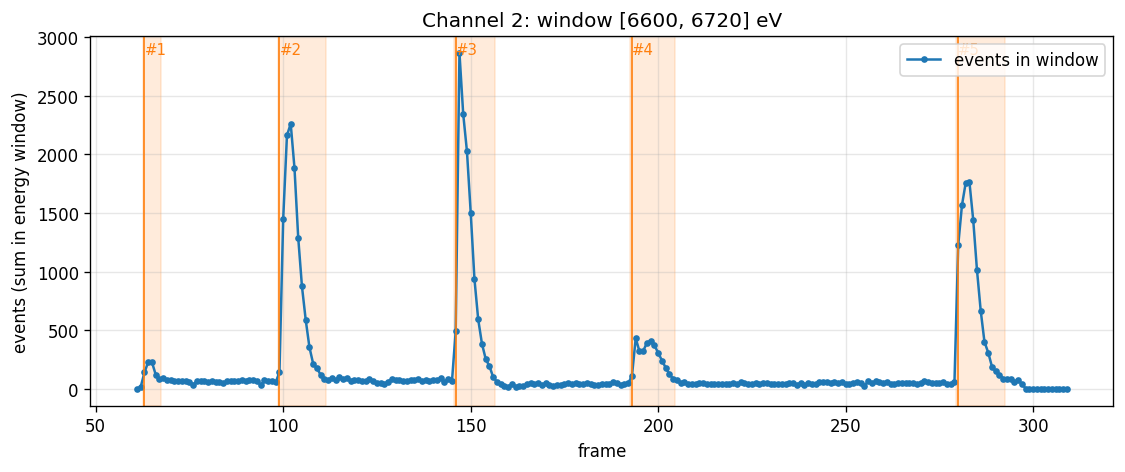

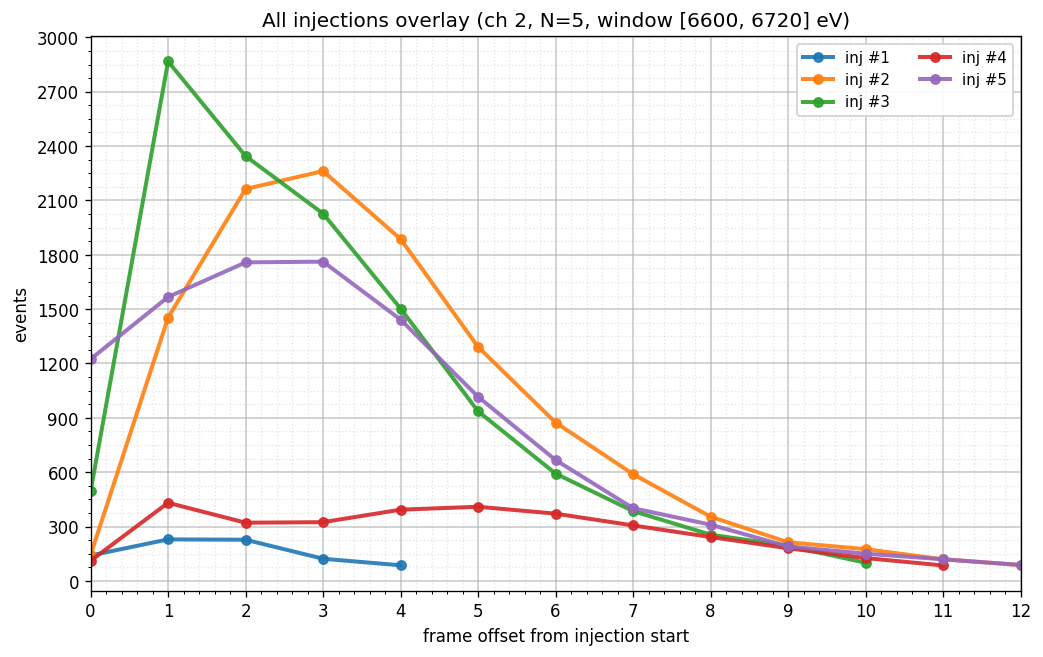

D:\ℱ Sci\IFPiLM\1st task\pha_lib\fit.py:89: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-(t - t_0) / tau) + C_bg
D:\ℱ Sci\IFPiLM\1st task\pha_lib\fit.py:98: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(_model, t_data, y_data, p0=p0, maxfev=5000)


fit_injection: requested end index 81 exceeds len(fn)=80; clipping to 80
fit_injection: requested end index 82 exceeds len(fn)=80; clipping to 80
fit_injection: requested end index 83 exceeds len(fn)=80; clipping to 80
fit_injection: requested end index 81 exceeds len(fn)=80; clipping to 80
fit_injection: requested end index 82 exceeds len(fn)=80; clipping to 80
fit_injection: requested end index 83 exceeds len(fn)=80; clipping to 80

Multi-discharge summary (channel 2):
  10-19: ch2 injections=5
  10-24: ch2 injections=4
  10-42: ch2 injections=3
  10-49: ch2 injections=1
  11-17: ch2 injections=4
  11-19: ch2 injections=5
  11-23: ch2 injections=3
  11-32: ch2 injections=3
  11-37: ch2 injections=3
  12-14: ch2 injections=3
  12-28: ch2 injections=6
  12-50: ch2 injections=3
  12-58: ch2 injections=3
  13-17: ch2 injections=2
  13-51: ch2 injections=6
  test: ch2 injections=5


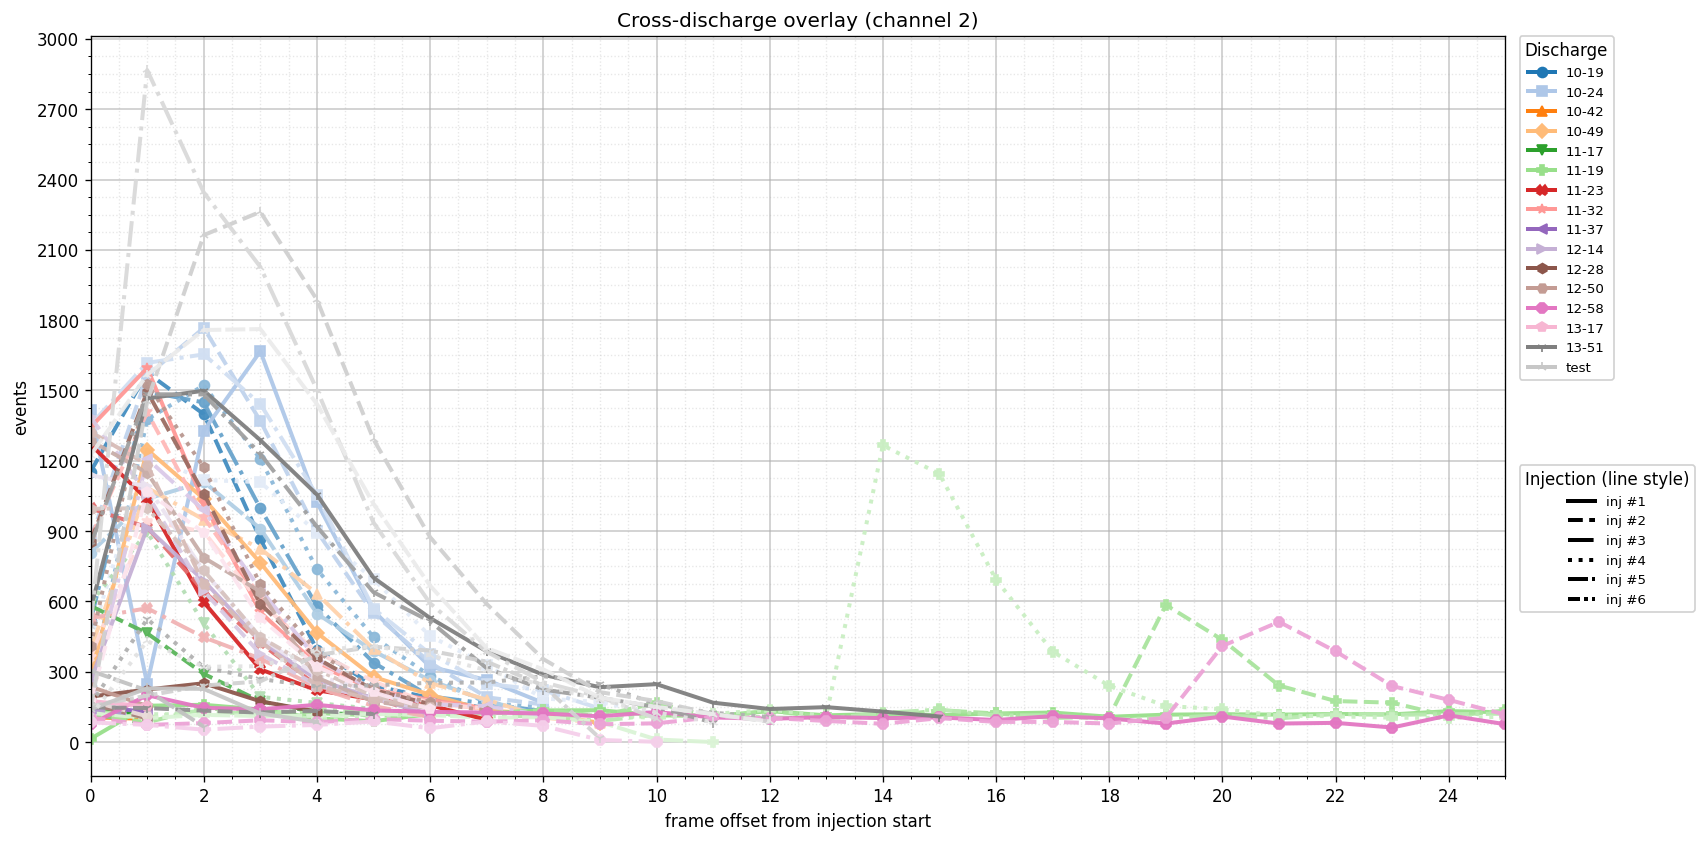

In [ ]:
# --- Single-discharge diagnostics (test folder) ---
# Load one compact test discharge to validate pipeline behavior quickly.
FOLDER_PATH = r"data\test"
DISCHARGE = io.load_test_folder(FOLDER_PATH, discharge_id="XP_big_eye")

# Analysis config: energy window + adaptive fit bounds.
cfg = BigEyeConfig(
    line_energy_eV=6660.0,
    half_window_eV=60,
    n_points=3,
    adaptive_min_points=3,
    adaptive_max_points=15,
)

# Detection config: controls sensitivity and grouping of jump events.
detection_cfg = InjectionDetectionConfig(
    threshold_factor=2.0,
    min_jump=8.0,
    min_quiet_frames=1,
    min_separation_frames=2,
    max_frames_per_discharge=25,
)

# Run full trace -> detect -> fit pipeline for one discharge.
result = run_big_eye(
    DISCHARGE,
    cfg=cfg,
    channel_ids=None,
    detection_cfg=detection_cfg,
    use_adaptive_fit=True,
)

# Quick provenance + per-channel counts for sanity checks.
print("detection source:", result["detection_source"])
print("fit source:", result["fit_source"])
for ch, inj in result["detections"].items():
    print(f"ch {ch}: injections={len(inj)}")

# Max local injection length sets a convenient default x-range for overlays.
all_injections = [inj for inj_list in result["detections"].values() for inj in inj_list]
global_max_offset = max((inj.finish_frame - inj.start_frame for inj in all_injections), default=1)
print("global_max_offset:", global_max_offset)

# Prefer channel 2 for continuity with other cells; fallback to first available.
channel_for_plot = 2 if 2 in result["traces"] else sorted(result["traces"].keys())[0]
trace = result["traces"][channel_for_plot]
injections = result["detections"][channel_for_plot]

# Diagnostic 1: full timetrace with highlighted injection intervals.
fig, ax = plt.subplots(figsize=(11, 4))
plot_timetrace_with_injections(trace, injections, ax=ax)
plt.show()

# Diagnostic 2: aligned per-injection overlay for shape comparison.
fig, ax = plt.subplots(figsize=(10, 6))
plot_all_injections_one_graph(
    trace,
    injections,
    normalize_to_start=False,
    x_max_offset=global_max_offset,
    ax=ax,
)
plt.show()

# --- Multi-discharge overlay: all available folders ---
# Map human-readable labels to raw data folders.
multi_paths = {
    "10-19": r"data\2025-04-29--10-19",
    "10-24": r"data\2025-04-29--10-24",
    "10-42": r"data\2025-04-29--10-42",
    "10-49": r"data\2025-04-29--10-49",
    "11-17": r"data\2025-04-29--11-17",
    "11-19": r"data\2025-04-29--11-19",
    "11-23": r"data\2025-04-29--11-23",
    "11-32": r"data\2025-04-29--11-32",
    "11-37": r"data\2025-04-29--11-37",
    "12-14": r"data\2025-04-29--12-14",
    "12-28": r"data\2025-04-29--12-28",
    "12-50": r"data\2025-04-29--12-50",
    "12-58": r"data\2025-04-29--12-58",
    "13-17": r"data\2025-04-29--13-17",
    "13-51": r"data\2025-04-29--13-51",
    "test":  r"data\test",
}

# Load all discharges once.
discharge_map = {
    name: io.load_test_folder(path, discharge_id=f"XP_{name}")
    for name, path in multi_paths.items()
}

# Run same pipeline for each discharge (heavy step reused by later cells).
results_by_discharge = {
    name: run_big_eye(
        d_obj,
        cfg=cfg,
        channel_ids=None,
        detection_cfg=detection_cfg,
        use_adaptive_fit=True,
    )
    for name, d_obj in discharge_map.items()
}

print("\nMulti-discharge summary (channel 2):")
for name, r in results_by_discharge.items():
    n_inj_ch2 = len(r["detections"].get(2, []))
    print(f"  {name}: ch2 injections={n_inj_ch2}")

# Wide figure leaves room for two legends on the right.
fig, ax = plt.subplots(figsize=(18, 8))
fig.subplots_adjust(right=0.78)
plot_injections_across_discharges(
    results_by_discharge,
    channel_id=2,
    injection_numbers=None,
    normalize_to_start=False,
    ax=ax,
    title="Cross-discharge overlay (channel 2)",
)
plt.show()


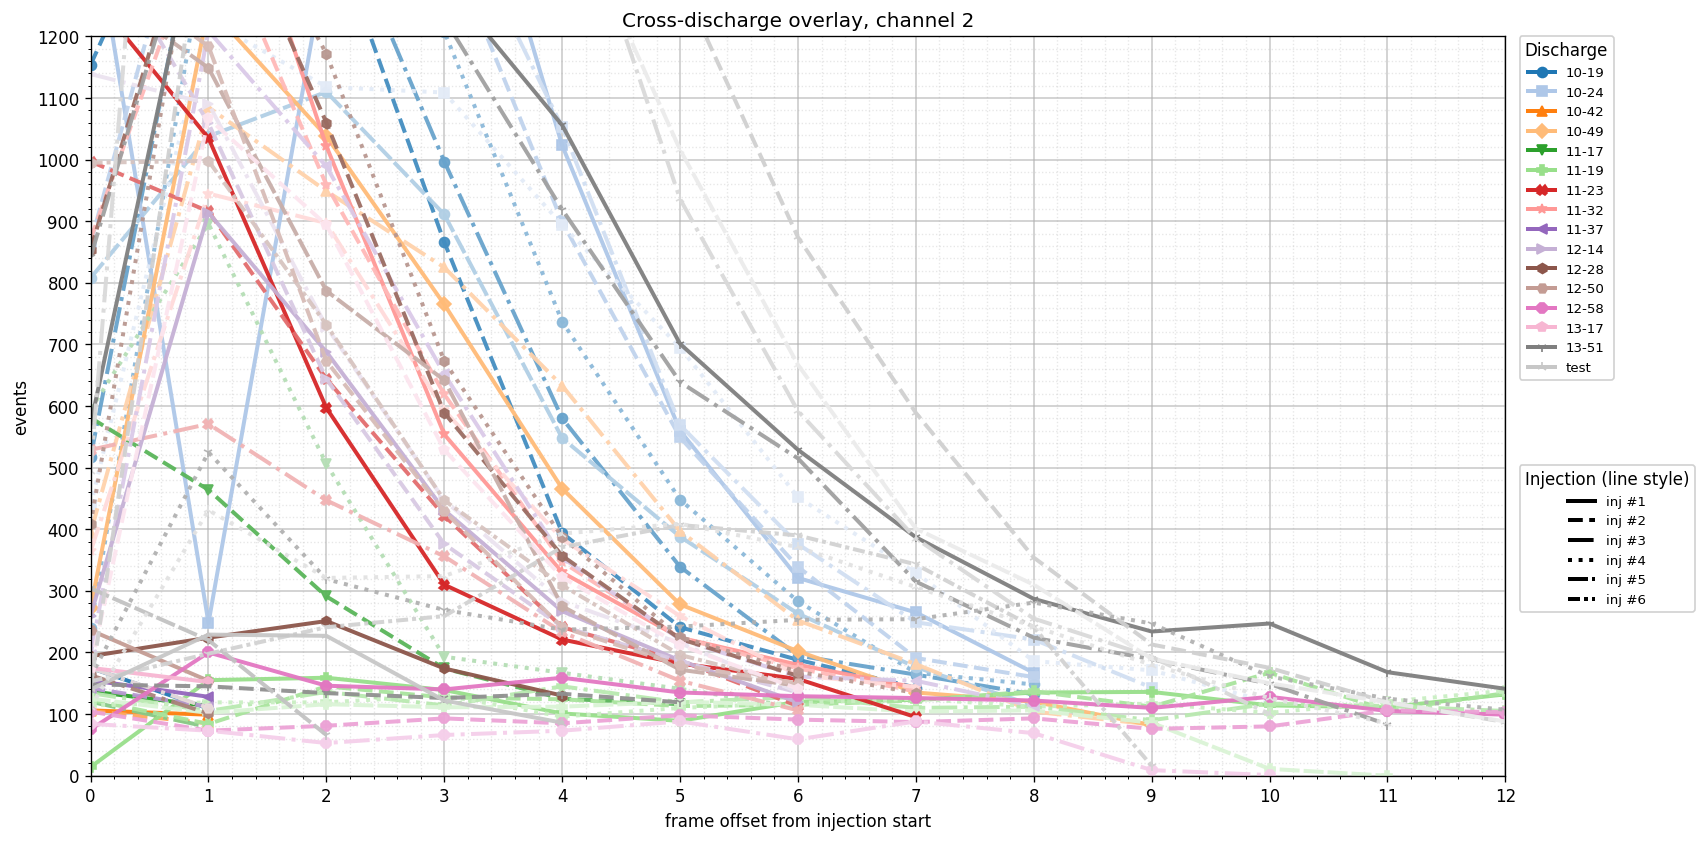

In [ ]:
# ── Re-plot only: cross-discharge overlay with fixed axis limits ──────────────
# Uses already-computed `results_by_discharge` — no recalculation.

# This cell is for fast visual tuning of limits/style only.
fig, ax = plt.subplots(figsize=(18, 8))
plot_injections_across_discharges(
    results_by_discharge,
    channel_id=channel_for_plot,
    ax=ax,
)

# Lock axes to shared comparison window used throughout notebook.
ax.set_xlim(0, 12)
ax.set_ylim(0, 1200)
fig.subplots_adjust(right=0.78)
plt.show()


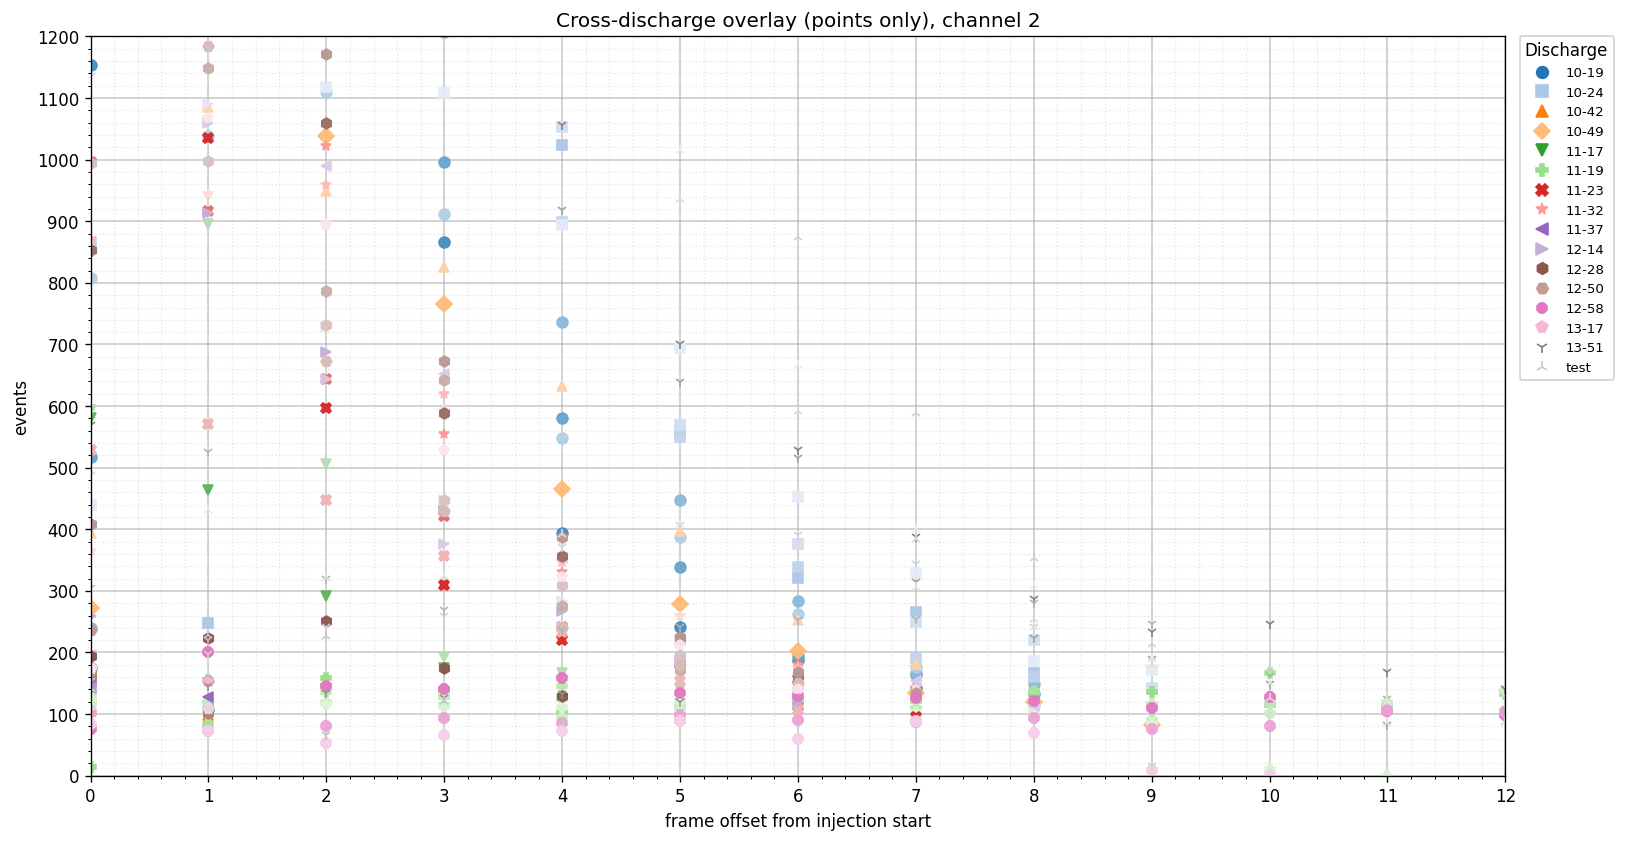

In [ ]:
# ── Re-plot: points only (no lines) ──────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# Fixed marker/color palettes to keep discharge identity stable across plots.
marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "H", "8", "p", "1", "2"]
base_cmap = plt.get_cmap("tab20")
discharge_names = list(results_by_discharge.keys())

# Per-discharge visual encodings.
base_color_by_discharge = {n: base_cmap(i % base_cmap.N) for i, n in enumerate(discharge_names)}
marker_by_discharge     = {n: marker_cycle[i % len(marker_cycle)] for i, n in enumerate(discharge_names)}

def _shade(base_rgba, level):
    # Shade local injections by blending the discharge base color toward white.
    level = float(np.clip(level, 0.0, 1.0))
    r, g, b, a = base_rgba
    return (1-(1-r)*level, 1-(1-g)*level, 1-(1-b)*level, a)

fig, ax = plt.subplots(figsize=(18, 8))
ch = channel_for_plot

for i, (d_name, res) in enumerate(results_by_discharge.items()):
    # Read one discharge result for selected channel.
    trace  = res["traces"].get(ch)
    if trace is None:
        continue
    fn, y  = trace.frame_numbers, trace.values
    injections = res["detections"].get(ch, [])
    n_local = len(injections)
    base   = base_color_by_discharge[d_name]
    mkr    = marker_by_discharge[d_name]

    for k, inj in enumerate(injections):
        # Keep samples inside this injection only.
        mask = (fn >= inj.start_frame) & (fn <= inj.finish_frame)
        if not np.any(mask):
            continue

        # Align each curve by injection start (x=0 at start frame).
        x_local = fn[mask].astype(float) - float(inj.start_frame)
        y_local = y[mask].astype(float)

        # First injection is darkest, later injections become lighter shades.
        level   = 1.0 if n_local == 1 else 1.0 - 0.65 * (k / (n_local - 1))
        ax.plot(
            x_local,
            y_local,
            linestyle="none",
            marker=mkr,
            color=_shade(base, level),
            ms=6.5,
            alpha=0.95,
        )

# Keep same plotting window as other comparison cells.
ax.set_xlim(0, 12)
ax.set_ylim(0, 1200)
ax.set_xlabel("frame offset from injection start")
ax.set_ylabel("events")
ax.set_title(f"Cross-discharge overlay (points only), channel {ch}")
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=16, integer=True))
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
ax.minorticks_on()
ax.grid(which="major", alpha=0.65, linewidth=1.0)
ax.grid(which="minor", alpha=0.30, linestyle=":", linewidth=0.8)

# Legend contains discharge identity only (color + marker), no injection lines here.
disch_handles = [
    Line2D([0],[0], color=base_color_by_discharge[n], linestyle="none",
           marker=marker_by_discharge[n], ms=7, label=n)
    for n in discharge_names
]
ax.legend(handles=disch_handles, title="Discharge", loc="upper left",
          bbox_to_anchor=(1.01, 1.0), fontsize=8, framealpha=0.9, borderaxespad=0)
fig.subplots_adjust(right=0.78)
plt.show()


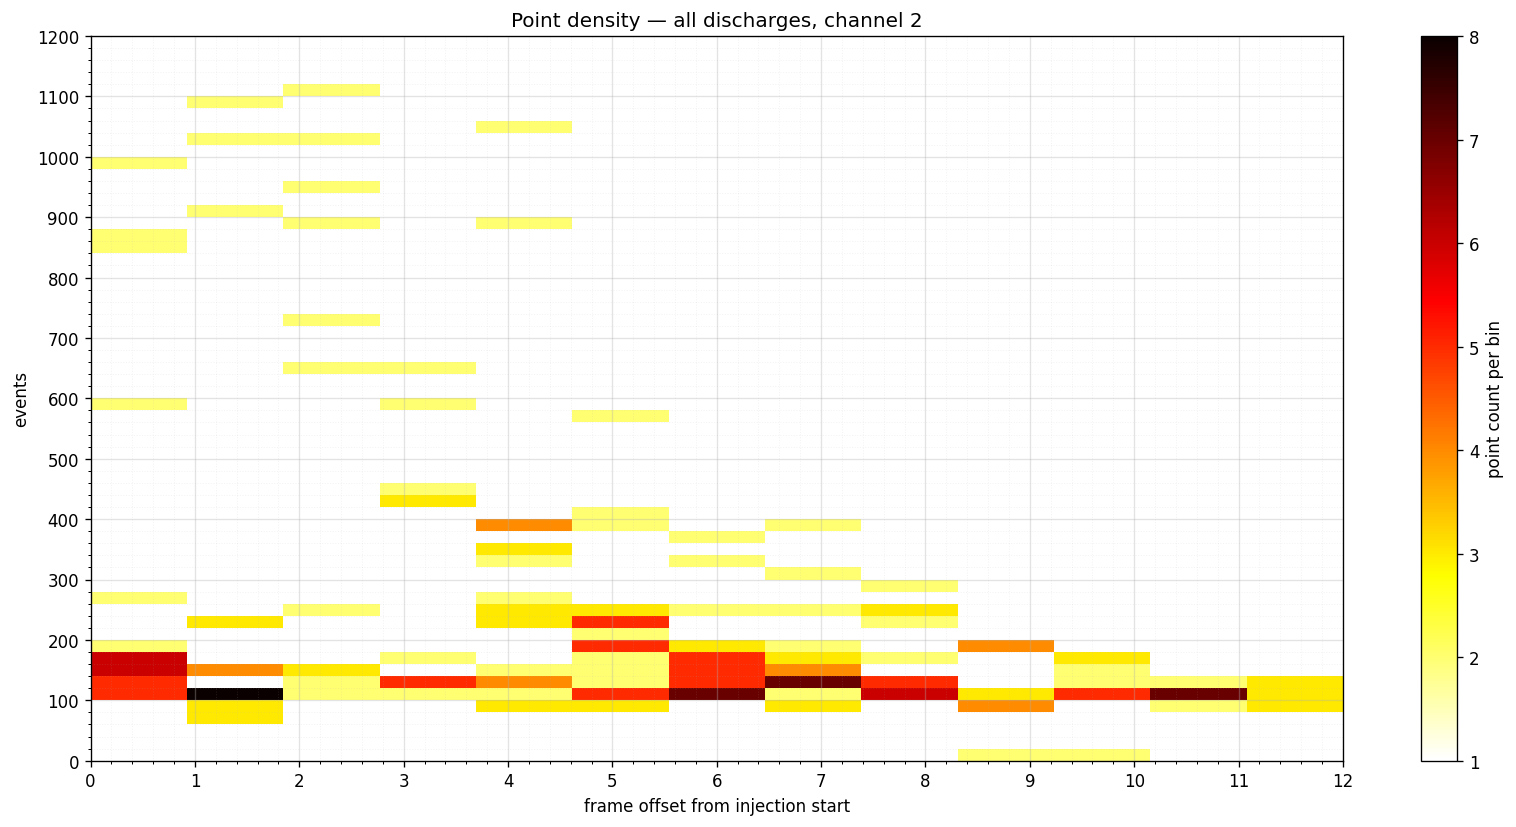

In [ ]:
# ── Density map: 2D histogram of all points across all discharges ─────────────
# Collect all (x_offset, events) points from every discharge/injection.
xs, ys = [], []
for res in results_by_discharge.values():
    tr = res["traces"].get(channel_for_plot)
    if tr is None:
        continue

    # Raw trace arrays for this discharge/channel.
    fn_d, y_d = tr.frame_numbers, tr.values
    for inj in res["detections"].get(channel_for_plot, []):
        # Restrict to one injection interval.
        mask = (fn_d >= inj.start_frame) & (fn_d <= inj.finish_frame)
        if not np.any(mask):
            continue

        # Shift x to local injection time and append all points.
        x_local = fn_d[mask].astype(float) - float(inj.start_frame)
        y_local = y_d[mask].astype(float)
        xs.extend(x_local.tolist())
        ys.extend(y_local.tolist())

# Convert lists once, then feed plotting/stat operations.
xs = np.array(xs)
ys = np.array(ys)

fig, ax = plt.subplots(figsize=(14, 7))
h = ax.hist2d(
    xs, ys,
    bins=[13, 60],          # 13 x-bins (0..12), 60 y-bins (0..1200)
    range=[[0, 12], [0, 1200]],
    cmap="hot_r",
    cmin=1,                 # hide empty bins (show as white)
)
# h[3] is the QuadMesh object used for colorbar mapping.
cbar = fig.colorbar(h[3], ax=ax, label="point count per bin")
ax.set_xlabel("frame offset from injection start")
ax.set_ylabel("events")
ax.set_title(f"Point density — all discharges, channel {channel_for_plot}")
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=13, integer=True))
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
ax.minorticks_on()
ax.grid(which="major", alpha=0.35, linewidth=0.8)
ax.grid(which="minor", alpha=0.15, linestyle=":", linewidth=0.6)
plt.tight_layout()
plt.show()


## Section B - Density Views

These cells transform all injection points into distribution views:
- 2D histogram density (bin counts),
- smooth KDE density field.

Use these to inspect where most trajectories concentrate in `(frame offset, events)` space.

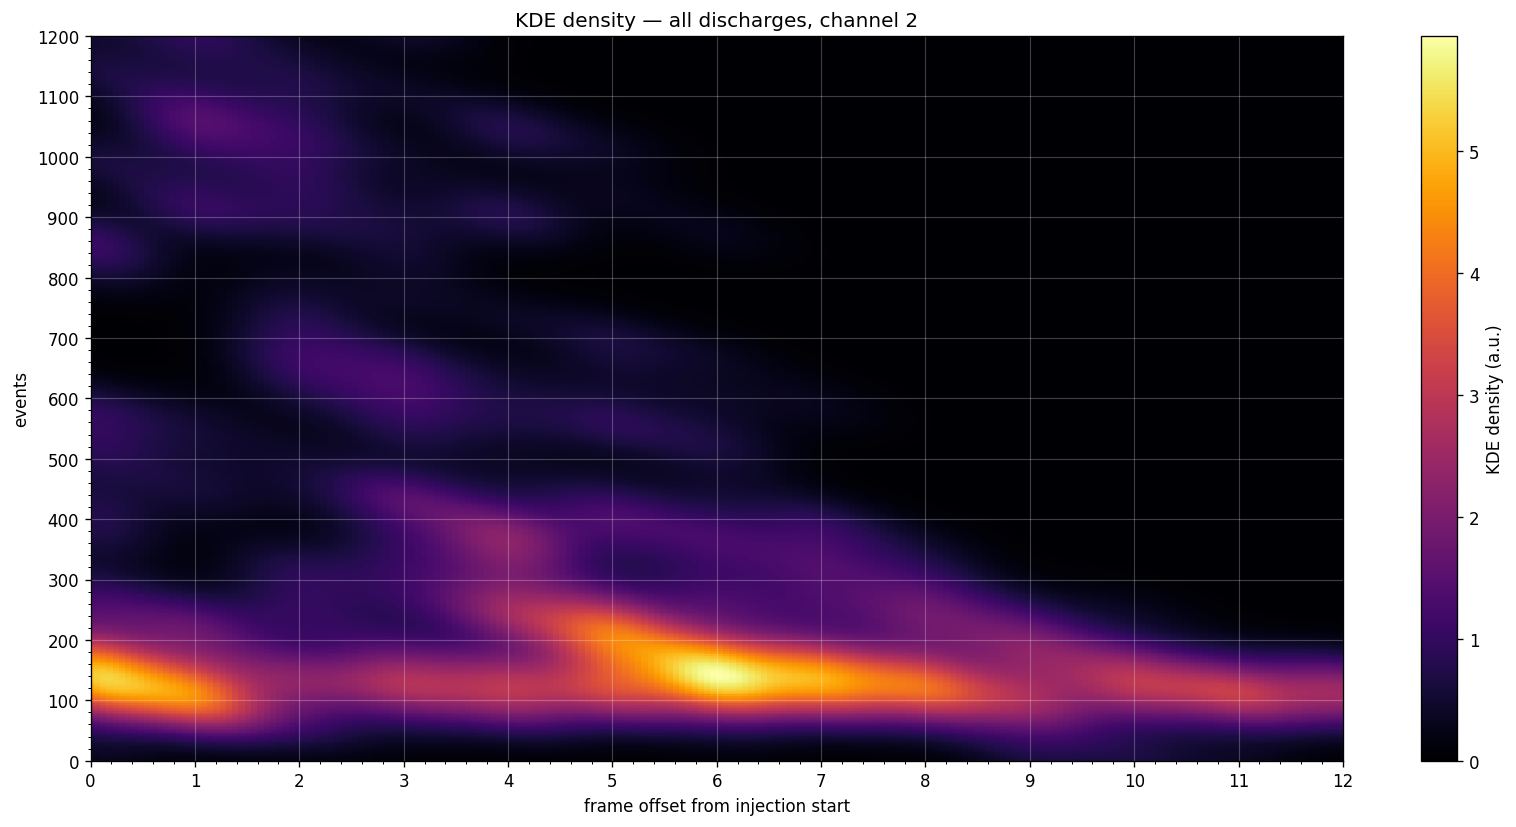

In [ ]:
# ── Smooth density map (KDE — each point spreads like a gaussian blob) ────────
from scipy.stats import gaussian_kde

# Normalise axes so x and y have comparable scale before KDE.
x_range = [0, 12]
y_range = [0, 1200]

# Scale xs to [0,1] and ys to [0,1] for bandwidth estimation stability.
xs_n = (xs - x_range[0]) / (x_range[1] - x_range[0])
ys_n = (ys - y_range[0]) / (y_range[1] - y_range[0])

kde = gaussian_kde(
    np.vstack([xs_n, ys_n]),
    bw_method=0.08,   # larger = more spread / smoother blobs; try 0.05–0.15
)

# Evaluate KDE on dense normalized grid.
nx, ny = 200, 400
xi = np.linspace(0, 1, nx)
yi = np.linspace(0, 1, ny)
Xi, Yi = np.meshgrid(xi, yi)
Z = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.pcolormesh(
    # Map normalized grid back to physical axis units for display.
    xi * (x_range[1] - x_range[0]) + x_range[0],
    yi * (y_range[1] - y_range[0]) + y_range[0],
    Z,
    cmap="inferno",
    shading="auto",
)
cbar = fig.colorbar(im, ax=ax, label="KDE density (a.u.)")
ax.set_xlabel("frame offset from injection start")
ax.set_ylabel("events")
ax.set_title(f"KDE density — all discharges, channel {channel_for_plot}")
ax.set_xlim(*x_range)
ax.set_ylim(*y_range)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=13, integer=True))
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
ax.minorticks_on()
ax.grid(which="major", alpha=0.25, linewidth=0.7, color="white")
plt.tight_layout()
plt.show()


Total injections collected: 59
  min=88  max=2867  mean=880


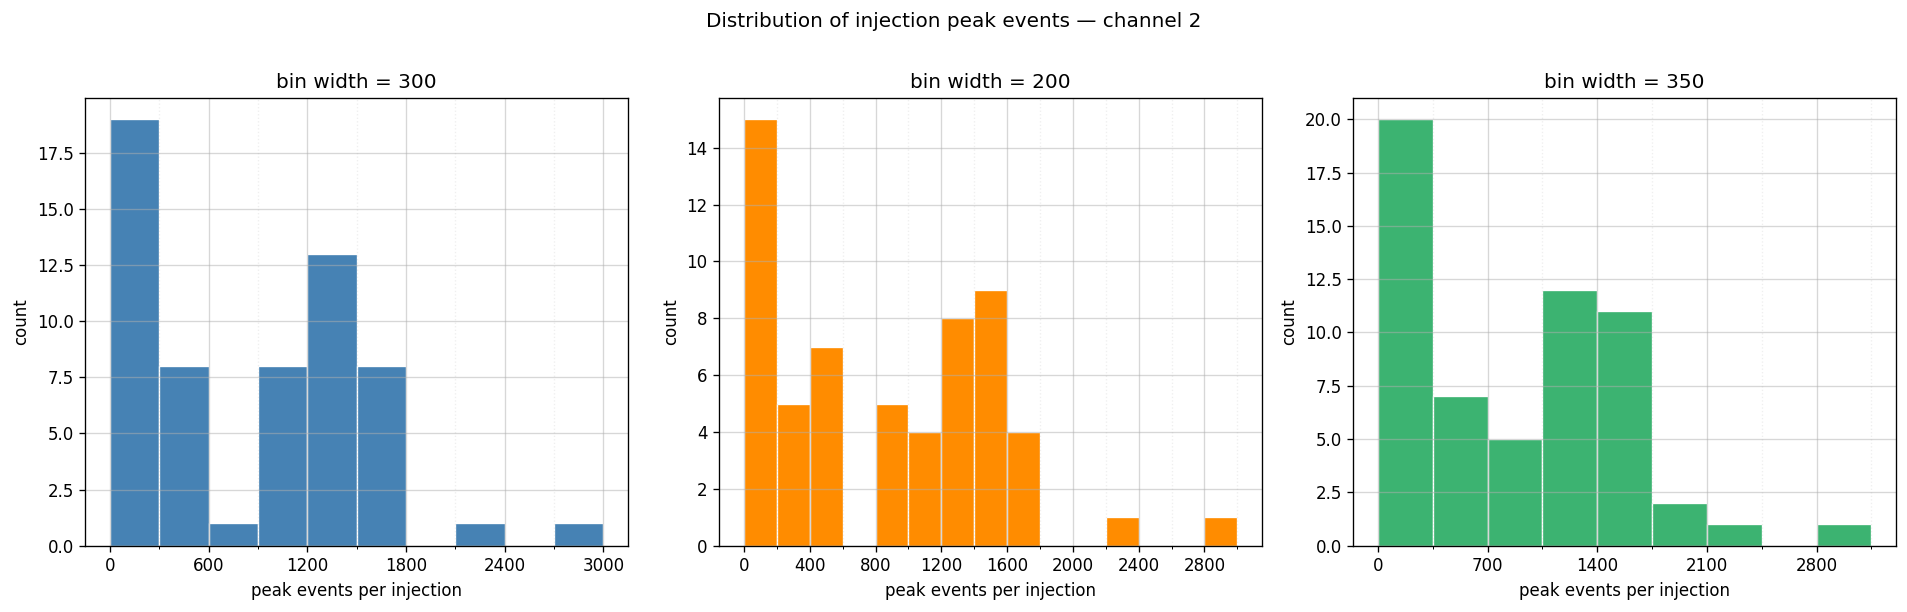

In [ ]:
# ── Max events per injection — histograms with 3 bin widths ──────────────────
# Collect max value of each injection from already-computed results.
max_vals = []
for res in results_by_discharge.values():
    tr = res["traces"].get(channel_for_plot)
    if tr is None:
        continue

    # Access raw trace arrays once per discharge.
    fn_d, y_d = tr.frame_numbers, tr.values
    for inj in res["detections"].get(channel_for_plot, []):
        # Slice values inside injection bounds.
        mask = (fn_d >= inj.start_frame) & (fn_d <= inj.finish_frame)
        if not np.any(mask):
            continue

        # One scalar per injection: peak event count.
        max_vals.append(float(np.max(y_d[mask])))

max_vals = np.array(max_vals)
print(f"Total injections collected: {len(max_vals)}")
print(f"  min={max_vals.min():.0f}  max={max_vals.max():.0f}  mean={max_vals.mean():.0f}")

# Round upper bound to next 100 for cleaner bin edges and axis ticks.
v_min, v_max = 0, int(np.ceil(max_vals.max() / 100) * 100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, step, color in zip(
    axes,
    [300, 200, 350],
    ["steelblue", "darkorange", "mediumseagreen"],
):
    # Compare same data under different bin widths.
    bins = np.arange(v_min, v_max + step, step)
    ax.hist(max_vals, bins=bins, color=color, edgecolor="white", linewidth=0.8)
    ax.set_xlabel("peak events per injection")
    ax.set_ylabel("count")
    ax.set_title(f"bin width = {step}")

    # Major ticks are coarser; minor ticks show every bin step.
    ax.xaxis.set_major_locator(mticker.MultipleLocator(step * 2))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(step))
    ax.grid(which="major", alpha=0.5)
    ax.grid(which="minor", alpha=0.2, linestyle=":")

fig.suptitle(f"Distribution of injection peak events — channel {channel_for_plot}", y=1.01)
plt.tight_layout()
plt.show()


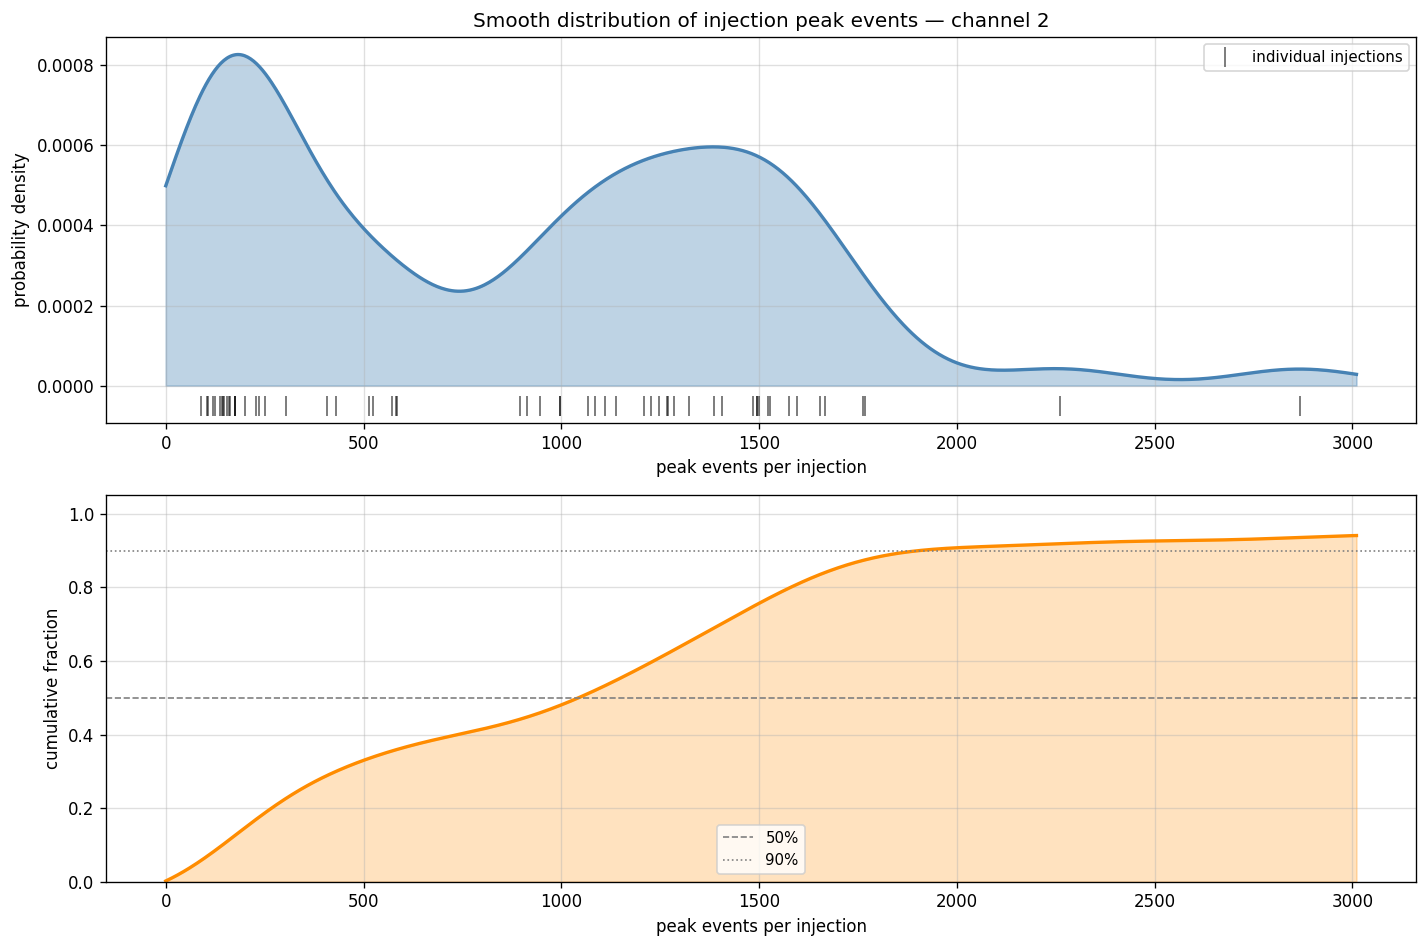

In [ ]:
# ── Smooth distribution of injection peak events (KDE) ───────────────────────
from scipy.stats import gaussian_kde

# Dense x-grid for smooth PDF/CDF visualization.
x_eval = np.linspace(0, max_vals.max() * 1.05, 800)
kde_peaks = gaussian_kde(max_vals, bw_method=0.25)
density = kde_peaks(x_eval)

# Numerical integral of KDE approximates the cumulative distribution (CDF).
dx = x_eval[1] - x_eval[0]
cumulative = np.cumsum(density) * dx  # ~CDF, normalized near 0→1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top panel: PDF-like KDE curve with rug marks for each observed injection.
ax1.fill_between(x_eval, density, alpha=0.35, color="steelblue")
ax1.plot(x_eval, density, color="steelblue", lw=2)
ax1.plot(
    max_vals,
    np.zeros_like(max_vals) - 0.00005,
    "|",
    color="black",
    ms=12,
    alpha=0.6,
    label="individual injections",
)
ax1.set_ylabel("probability density")
ax1.set_xlabel("peak events per injection")
ax1.set_title(f"Smooth distribution of injection peak events — channel {channel_for_plot}")
ax1.legend(fontsize=9)
ax1.tick_params(axis="x", labelbottom=True)
ax1.grid(alpha=0.4)

# Bottom panel: CDF with 50% and 90% reference levels.
ax2.fill_between(x_eval, cumulative, alpha=0.25, color="darkorange")
ax2.plot(x_eval, cumulative, color="darkorange", lw=2)
ax2.axhline(0.5, color="gray", lw=1, linestyle="--", label="50%")
ax2.axhline(0.9, color="gray", lw=1, linestyle=":",  label="90%")
ax2.set_ylabel("cumulative fraction")
ax2.set_xlabel("peak events per injection")
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.show()


Selected injections (peak < 700): 27
Adaptive y max: 643.5 (selected peak max = 585.0)


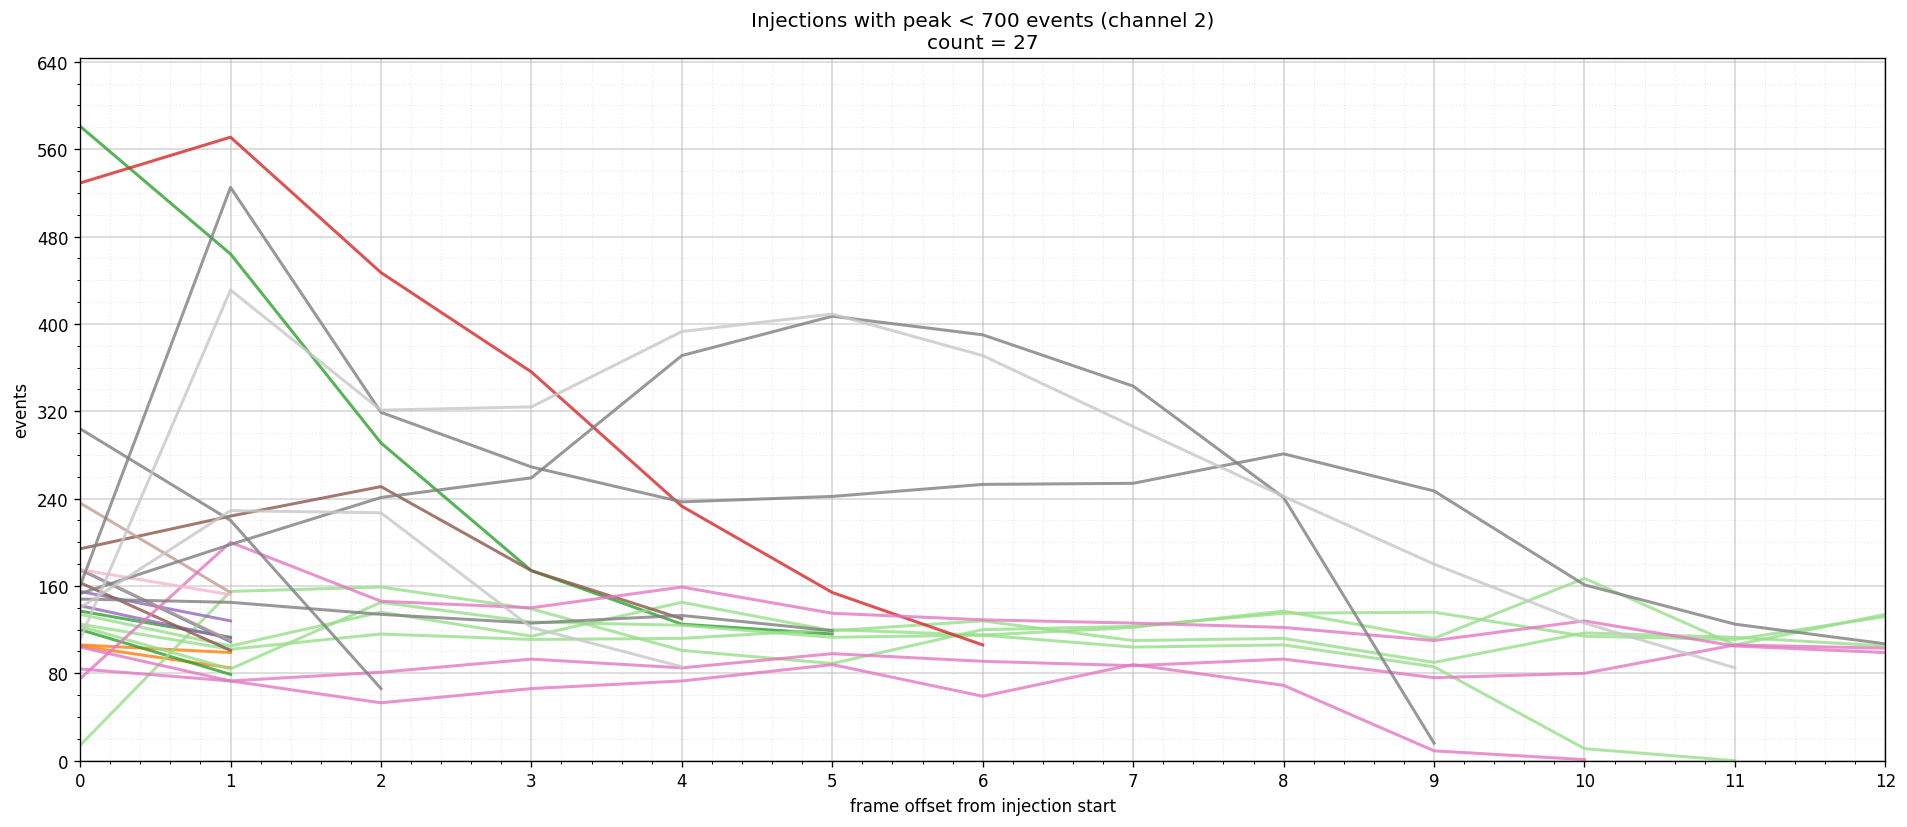

In [ ]:
# ── Line graph: injections with peak value < 700 events (no recalculation) ─────
peak_threshold = 700.0

fig, ax = plt.subplots(figsize=(16, 7))
base_cmap = plt.get_cmap("tab20")

# Track filtered population size and max peak for adaptive y-axis.
selected_count = 0
selected_peak_max = 0.0
discharge_names = list(results_by_discharge.keys())

for i, d_name in enumerate(discharge_names):
    res = results_by_discharge[d_name]
    tr = res["traces"].get(channel_for_plot)
    if tr is None:
        continue

    fn_d, y_d = tr.frame_numbers, tr.values
    color = base_cmap(i % base_cmap.N)

    for inj in res["detections"].get(channel_for_plot, []):
        # Build local injection trace.
        mask = (fn_d >= inj.start_frame) & (fn_d <= inj.finish_frame)
        if not np.any(mask):
            continue

        x_local = fn_d[mask].astype(float) - float(inj.start_frame)
        y_local = y_d[mask].astype(float)
        peak_val = float(np.max(y_local))

        # Keep only low-peak injections below requested threshold.
        if peak_val < peak_threshold:
            ax.plot(x_local, y_local, color=color, lw=1.8, alpha=0.8)
            selected_count += 1
            selected_peak_max = max(selected_peak_max, peak_val)

# Adaptive y-range: selected max + headroom (min 40 events).
if selected_count > 0:
    y_top = selected_peak_max + max(0.10 * selected_peak_max, 40.0)
else:
    y_top = peak_threshold

ax.set_title(
    f"Injections with peak < {int(peak_threshold)} events (channel {channel_for_plot})\n"
    f"count = {selected_count}"
)
ax.set_xlabel("frame offset from injection start")
ax.set_ylabel("events")
ax.set_xlim(0, 12)
ax.set_ylim(0, y_top)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=13, integer=True))
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=10))
ax.minorticks_on()
ax.grid(which="major", alpha=0.55, linewidth=0.9)
ax.grid(which="minor", alpha=0.25, linestyle=":", linewidth=0.7)

print(f"Selected injections (peak < {int(peak_threshold)}): {selected_count}")
print(f"Adaptive y max: {y_top:.1f} (selected peak max = {selected_peak_max:.1f})")
plt.tight_layout()
plt.show()


## Section C - Peak and Filter Analysis

These cells focus on peak-event statistics and constrained subsets:
- histogram/KDE/CDF of peak values,
- overlays for filtered injections (`peak < threshold`, `length >= N`).

This section is useful for comparing rare vs typical injection shapes without rerunning detection.

Filtered injections (length >= 4 and peak < 700): 15


,discharge,injection_no,start,finish,length,peak
0,11-17,2,108,113,6,581.0
1,11-19,1,63,88,26,159.0
2,11-19,2,91,116,26,585.0
3,11-19,3,123,148,26,145.0
4,11-19,5,179,190,12,125.0
5,11-23,3,273,279,7,571.0
6,12-28,1,87,91,5,251.0
7,12-58,1,63,88,26,200.0
8,12-58,2,90,115,26,513.0
9,12-58,3,125,135,11,88.0


Adaptive y max: 643.5 (selected peak max = 585.0)


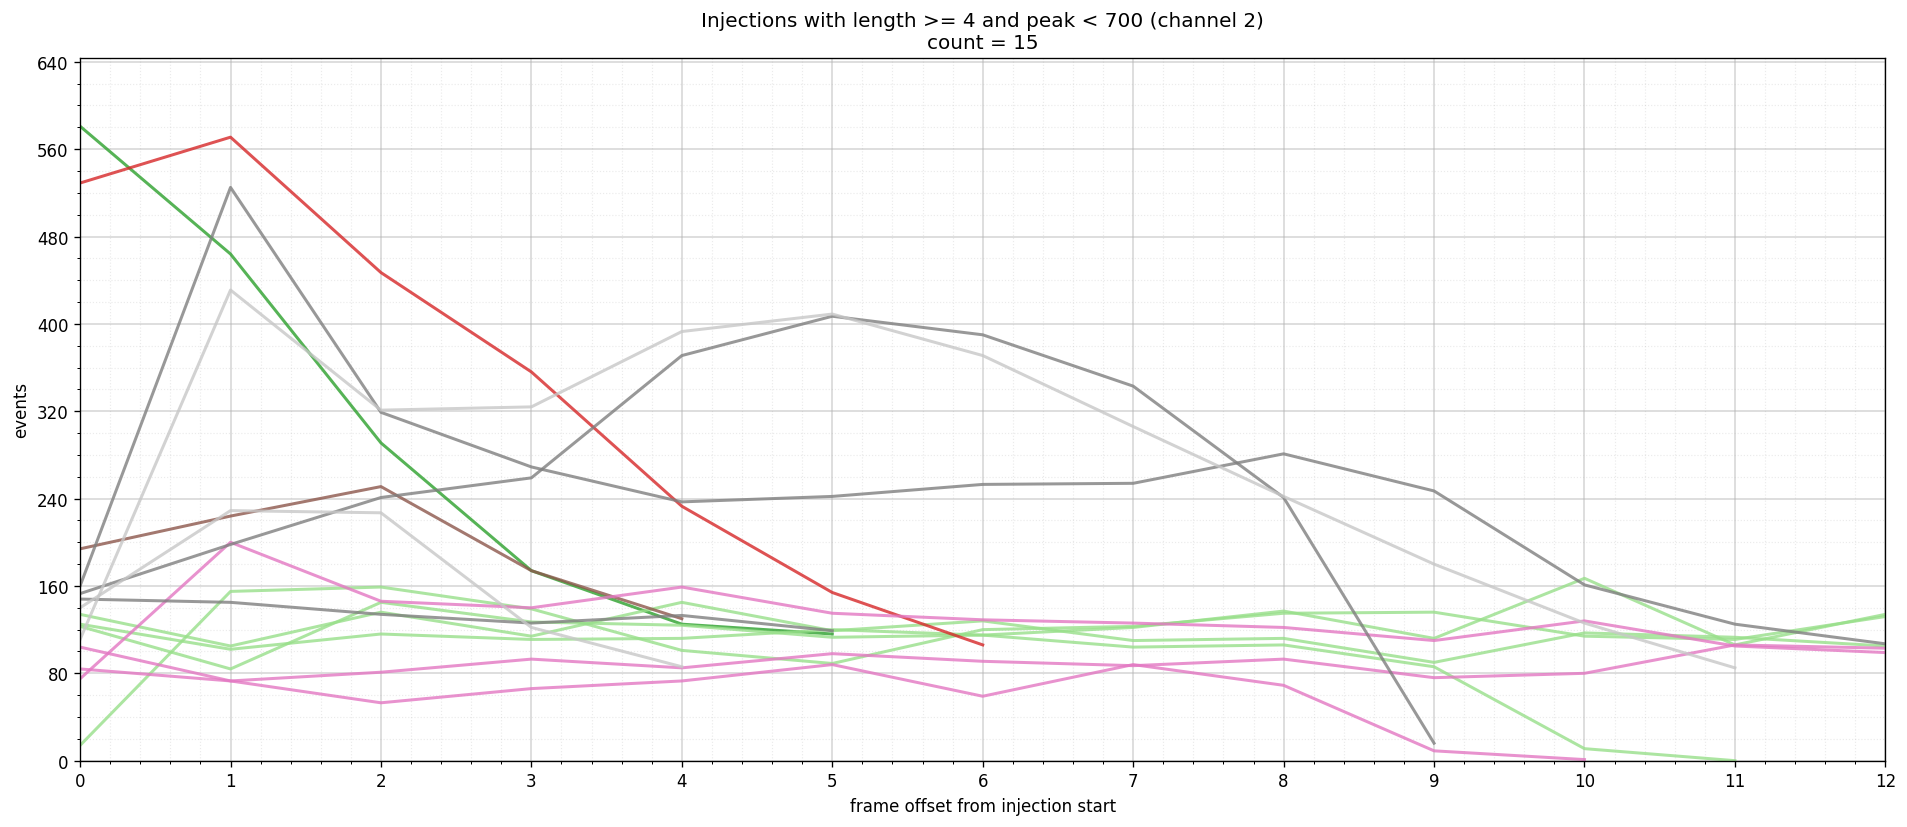

In [ ]:
# ── Line graph: injections with length >= 4 and peak < 700 (new filtered set) ──
peak_threshold = 700.0
min_len = 4

fig, ax = plt.subplots(figsize=(16, 7))
base_cmap = plt.get_cmap("tab20")

# Keep full metadata for inspection table + plotting stats.
filtered_injections = []
selected_peak_max = 0.0
discharge_names = list(results_by_discharge.keys())

for i, d_name in enumerate(discharge_names):
    res = results_by_discharge[d_name]
    tr = res["traces"].get(channel_for_plot)
    if tr is None:
        continue

    fn_d, y_d = tr.frame_numbers, tr.values
    color = base_cmap(i % base_cmap.N)

    for inj in res["detections"].get(channel_for_plot, []):
        # Extract one injection segment in local coordinates.
        mask = (fn_d >= inj.start_frame) & (fn_d <= inj.finish_frame)
        if not np.any(mask):
            continue

        x_local = fn_d[mask].astype(float) - float(inj.start_frame)
        y_local = y_d[mask].astype(float)
        peak_val = float(np.max(y_local))
        inj_len = int(inj.finish_frame - inj.start_frame + 1)

        # Apply both filters: minimum duration and peak cap.
        if inj_len >= min_len and peak_val < peak_threshold:
            filtered_injections.append({
                "discharge": d_name,
                "injection_no": int(inj.injection_no),
                "start": int(inj.start_frame),
                "finish": int(inj.finish_frame),
                "length": inj_len,
                "peak": peak_val,
            })
            ax.plot(x_local, y_local, color=color, lw=1.8, alpha=0.8)
            selected_peak_max = max(selected_peak_max, peak_val)

selected_count = len(filtered_injections)

# Adaptive y-range with headroom based on selected subset only.
if selected_count > 0:
    y_top = selected_peak_max + max(0.10 * selected_peak_max, 40.0)
else:
    y_top = peak_threshold

ax.set_title(
    f"Injections with length >= {min_len} and peak < {int(peak_threshold)} (channel {channel_for_plot})\n"
    f"count = {selected_count}"
)
ax.set_xlabel("frame offset from injection start")
ax.set_ylabel("events")
ax.set_xlim(0, 12)
ax.set_ylim(0, y_top)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=13, integer=True))
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=10))
ax.minorticks_on()
ax.grid(which="major", alpha=0.55, linewidth=0.9)
ax.grid(which="minor", alpha=0.25, linestyle=":", linewidth=0.7)

print(f"Filtered injections (length >= {min_len} and peak < {int(peak_threshold)}): {selected_count}")
if selected_count > 0:
    # Sort for easier scanning of discharge/injection order.
    filtered_df = pd.DataFrame(filtered_injections).sort_values(["discharge", "injection_no"])
    display(filtered_df)
    print(f"Adaptive y max: {y_top:.1f} (selected peak max = {selected_peak_max:.1f})")

plt.tight_layout()
plt.show()


Filtered injections (length >= 4): 47


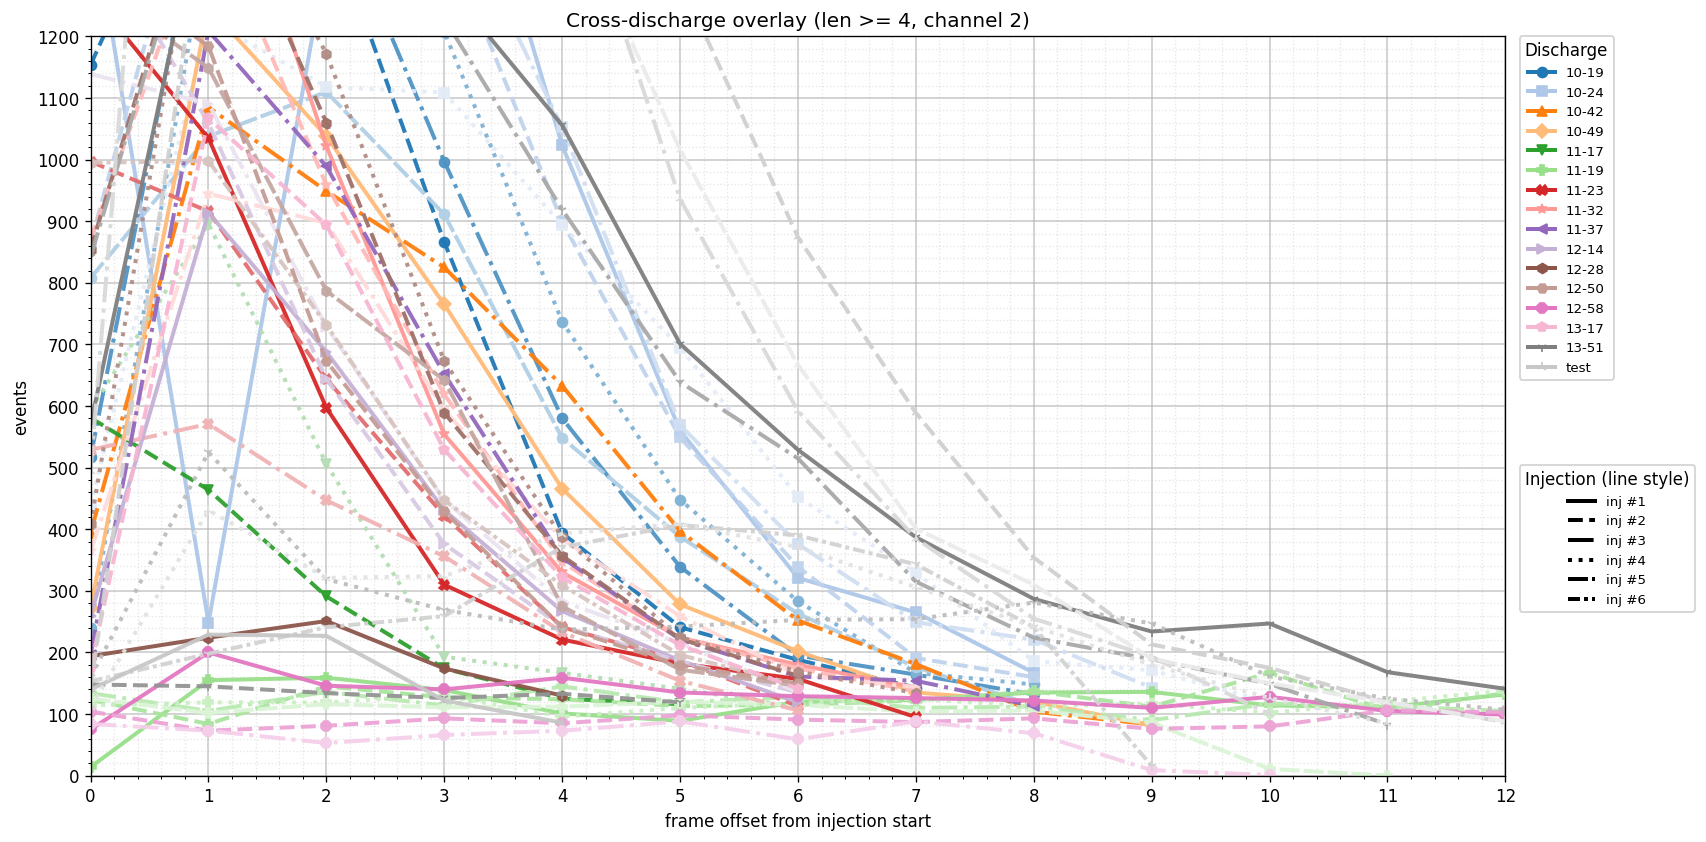

In [ ]:
# ── Cross-discharge style plot (as Cell 4): only injections with length >= 4 ───
min_len = 4

# Build filtered view of already-computed results (no recalculation).
results_len_ge4 = {}
selected_count = 0

for d_name, res in results_by_discharge.items():
    # Shallow-copy parent dicts and replace only detections for target channel.
    res_filtered = dict(res)
    det_filtered = dict(res["detections"])

    injs = res["detections"].get(channel_for_plot, [])
    injs_len_ge4 = [
        inj for inj in injs
        if int(inj.finish_frame - inj.start_frame + 1) >= min_len
    ]

    det_filtered[channel_for_plot] = injs_len_ge4
    res_filtered["detections"] = det_filtered
    results_len_ge4[d_name] = res_filtered
    selected_count += len(injs_len_ge4)

fig, ax = plt.subplots(figsize=(18, 8))
fig.subplots_adjust(right=0.78)
plot_injections_across_discharges(
    results_len_ge4,
    channel_id=channel_for_plot,
    injection_numbers=None,
    normalize_to_start=False,
    ax=ax,
    title=f"Cross-discharge overlay (len >= {min_len}, channel {channel_for_plot})",
)
ax.set_xlim(0, 12)
ax.set_ylim(0, 1200)

print(f"Filtered injections (length >= {min_len}): {selected_count}")
plt.show()


Count for KDE (length > 4): 47


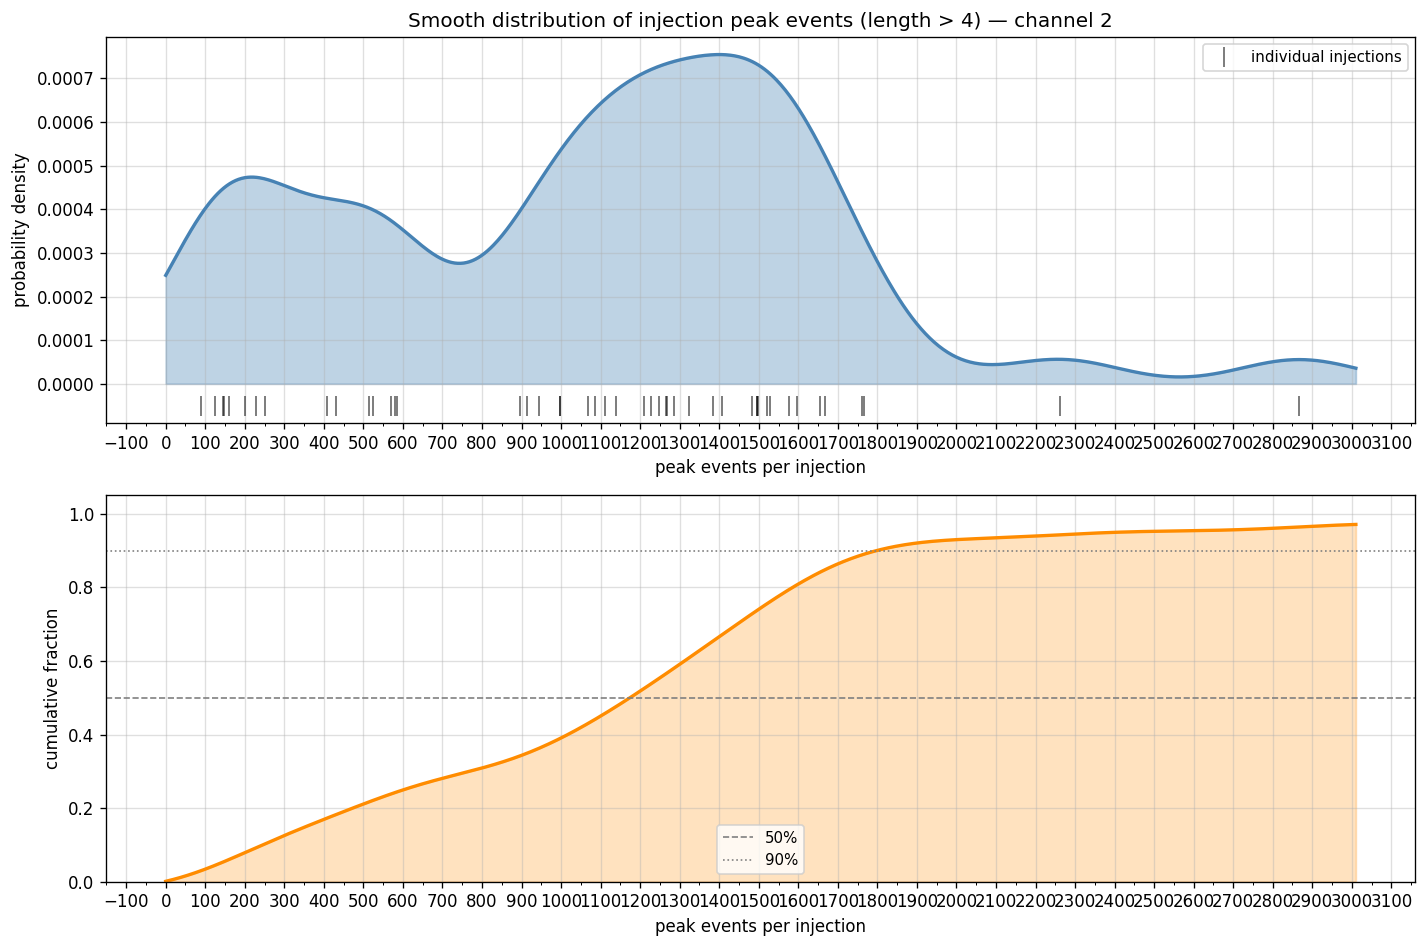

In [ ]:
# ── Cell 9 style KDE/CDF for injections with length > 4 (using existing filtered set) ──
from scipy.stats import gaussian_kde

min_len_for_kde = 5  # length > 4

# Reuse prepared filtered structure; do not recompute detection from raw files.
max_vals_len_gt4 = []
for d_name, res in results_len_ge4.items():
    tr = res["traces"].get(channel_for_plot)
    if tr is None:
        continue

    fn_d, y_d = tr.frame_numbers, tr.values
    for inj in res["detections"].get(channel_for_plot, []):
        inj_len = int(inj.finish_frame - inj.start_frame + 1)
        if inj_len < min_len_for_kde:
            continue

        # Peak extraction per injection for KDE input sample.
        mask = (fn_d >= inj.start_frame) & (fn_d <= inj.finish_frame)
        if not np.any(mask):
            continue

        max_vals_len_gt4.append(float(np.max(y_d[mask])))

max_vals_len_gt4 = np.array(max_vals_len_gt4, dtype=float)
print(f"Count for KDE (length > 4): {len(max_vals_len_gt4)}")

if len(max_vals_len_gt4) < 2:
    print("Not enough points for KDE (need at least 2).")
else:
    # Evaluate smooth PDF-like curve and integrate to CDF.
    x_eval = np.linspace(0, max_vals_len_gt4.max() * 1.05, 800)
    kde_peaks = gaussian_kde(max_vals_len_gt4, bw_method=0.25)
    density = kde_peaks(x_eval)

    dx = x_eval[1] - x_eval[0]
    cumulative = np.cumsum(density) * dx

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Top: KDE density + rug marks (raw sample positions).
    ax1.fill_between(x_eval, density, alpha=0.35, color="steelblue")
    ax1.plot(x_eval, density, color="steelblue", lw=2)
    ax1.plot(
        max_vals_len_gt4,
        np.zeros_like(max_vals_len_gt4) - 0.00005,
        "|",
        color="black",
        ms=12,
        alpha=0.6,
        label="individual injections",
    )
    ax1.set_ylabel("probability density")
    ax1.set_xlabel("peak events per injection")
    ax1.set_title(
        f"Smooth distribution of injection peak events (length > 4) — channel {channel_for_plot}"
    )
    ax1.legend(fontsize=9)
    ax1.tick_params(axis="x", labelbottom=True)
    ax1.grid(alpha=0.4)

    # Bottom: cumulative density with visual quantile references.
    ax2.fill_between(x_eval, cumulative, alpha=0.25, color="darkorange")
    ax2.plot(x_eval, cumulative, color="darkorange", lw=2)
    ax2.axhline(0.5, color="gray", lw=1, linestyle="--", label="50%")
    ax2.axhline(0.9, color="gray", lw=1, linestyle=":", label="90%")
    ax2.set_ylabel("cumulative fraction")
    ax2.set_xlabel("peak events per injection")
    ax2.set_ylim(0, 1.05)
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.4)

    # X-axis ticks: major every 100 (labels), minor every 50 (no labels).
    for a in (ax1, ax2):
        a.xaxis.set_major_locator(mticker.MultipleLocator(100))
        a.xaxis.set_minor_locator(mticker.MultipleLocator(50))

    plt.tight_layout()
    plt.show()
